# Etapa 4 - Modelagem Preditiva

Nesta etapa são desenvolvidos modelos de aprendizado de máquina para prever a via de transporte utilizada em operações de exportação brasileiras. O objetivo é construir modelos capazes de classificar o modal de transporte a partir das características da carga, da origem da exportação e do destino comercial.

Além da capacidade preditiva, também será realizada uma análise de interpretabilidade para identificar quais variáveis exercem maior influência sobre a escolha da via de transporte.

Serão avaliados dois modelos neste notebook:

- Regressão Logística (modelo simples e mais interpretável);
- Random Forest (modelo mais complexo e capaz de capturar relações não lineares).

Os modelos serão comparados utilizando métricas de desempenho apropriadas para problemas de classificação multiclasse.

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Carregamento da Base de Dados

A base de dados utilizada nesta etapa corresponde ao conjunto tratado e enriquecido durante as etapas anteriores do projeto.Esse conjunto já passou por alguns processos de limpeza, tratamento de inconsistências, integração de dados e engenharia de atributos.

In [69]:
# Carregando o Dataset
df = pd.read_csv('/Users/raqueloliveira/Desktop/CD/Trab Final/cleaned_exports_2025.csv')

## Análise da Variável Alvo

Antes da construção dos modelos, é importante compreender a distribuição da variável que será prevista. Neste projeto, o objetivo é prever a variável `transport_route`, que representa a via de transporte utilizada na exportação. A análise da distribuição permite identificar possíveis problemas de desbalanceamento entre as classes, algo comum em problemas reais de classificação.

In [71]:
# Distribuição da Variável Alvo
df["transport_route"].value_counts()

transport_route
1     913761
4     466747
7     290955
15     19913
0      16902
12       528
6        411
9        280
3        133
2         86
8         28
13         2
Name: count, dtype: int64

In [73]:
(
    df["transport_route"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

transport_route
1     53.44
4     27.30
7     17.02
15     1.16
0      0.99
12     0.03
6      0.02
9      0.02
3      0.01
2      0.01
8      0.00
13     0.00
Name: proportion, dtype: float64

### Desbalanceamento das Classes

Observa-se que algumas categorias possuem quantidade extremamente reduzida de registros quando comparadas às principais vias de transporte. Esse desbalanceamento pode dificultar o aprendizado dos modelos, levando-os a favorecer as classes majoritárias. Para reduzir esse problema, as classes com baixa representatividade são agrupadas em uma única categoria denominada **Other**.

# Criando o target

In [75]:
# Agrupamento das Classes Raras
main_routes = [1, 4, 7, 15, 0]

df["transport_route_grouped"] = np.where(
    df["transport_route"].isin(main_routes),
    df["transport_route"],
    "Other"
)

In [81]:
# Conferência do Novo Target
(
    df["transport_route_grouped"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

transport_route_grouped
1        53.44
4        27.30
7        17.02
15        1.16
0         0.99
Other     0.09
Name: proportion, dtype: float64

# Seleção de Atributos

## Features Numéricas
As variáveis numéricas representam características quantitativas da exportação, como peso líquido, valor FOB e quantidade exportada. Esses atributos fornecem informações relacionadas ao volume físico e ao valor econômico das operações.

In [85]:
numeric_features = [
    "net_weight_kg",
    "fob_value_usd",
    "value_per_kg",
    "statistical_quantity_export",
    "month",
    "quarter",
    "semester",
    "ncm_chapter",
    "is_mercosul",
    "is_coastal_state",
    "is_express_delivery"
]

## Features Categóricas
As variáveis categóricas representam informações geográficas e comerciais, como estado de origem, região de origem e país de destino. Essas informações podem influenciar diretamente a escolha do modal de transporte utilizado na operação.

In [88]:
categorical_features = [
    "origin_state",
    "origin_region",
    "country_name"
]

## Target
A variável alvo do problema é `transport_route_grouped`, que representa a via de transporte utilizada após o agrupamento das categorias raras. O problema é tratado como uma tarefa de classificação multiclasse supervisionada.

In [91]:
target = "transport_route_grouped"

# Separação - Treino e Teste
Nesta etapa são definidas as variáveis de entrada (features) e a variável que será prevista pelos modelos (target).

In [96]:
X = df[
    numeric_features +
    categorical_features
]

y = df[target]

O conjunto de dados é dividido em duas partes:

- Treino (80%)
- Teste (20%)

A divisão estratificada preserva a proporção das classes em ambos os conjuntos. Essa estratégia permite avaliar o desempenho dos modelos em dados não vistos durante o treinamento, reduzindo o risco de overfitting.

In [98]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1367796, 14)
(341950, 14)


# Pré-Processamento
Os modelos utilizados exigem que os dados estejam em formato numérico e sem valores ausentes.

Para isso são aplicadas as seguintes transformações:

- Imputação de valores ausentes;
- Padronização das variáveis numéricas;
- Codificação One-Hot das variáveis categóricas.

Todas as transformações são incorporadas ao pipeline de treinamento.

In [101]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# Modelo 1 - Logistic Regression
A Regressão Logística é um algoritmo de classificação supervisionada utilizado como modelo base em problemas de classificação. Trata-se de um classificador capaz de estimar probabilidades para cada classe.

Suas principais vantagens são:

- Simplicidade;
- Baixo custo computacional;
- Facilidade de interpretação.

Por outro lado, o modelo assume relações predominantemente lineares entre as variáveis de entrada e a variável alvo.

In [103]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [105]:
# Treinamento LR
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['net_weight_kg',
                                                   'fob_value_usd',
                                                   'value_per_kg',
                                                   'statistical_quantity_export',
                                                   'month', 'quarter',
                                                   'semester', 'ncm_chapter',
                                                   'is_mercosul',
                                                   'is_coastal_state',
                                                   'is_express_delivery']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['origin_state',
                                                   'origin_region',
                                                   'country_name'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [108]:
y_pred_logistic = logistic_pipeline.predict(
    X_test
)

## Avaliação do Modelo

Para avaliar o desempenho serão utilizadas as seguintes métricas:

- Accuracy: proporção de classificações corretas;
- F1 Macro: média do desempenho entre todas as classes;
- F1 Weighted: média ponderada pelo tamanho de cada classe.

A utilização conjunta dessas métricas é importante devido ao desbalanceamento presente na variável alvo.

In [110]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_f1_macro = f1_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

logistic_f1_weighted = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Accuracy:", logistic_accuracy)
print("F1 Macro:", logistic_f1_macro)
print("F1 Weighted:", logistic_f1_weighted)

Accuracy: 0.6221494370522006
F1 Macro: 0.4146207331533351
F1 Weighted: 0.681454881611081


In [112]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           0       0.08      0.69      0.14      3380
           1       0.90      0.67      0.77    182753
          15       0.20      0.99      0.34      3983
           4       0.59      0.52      0.56     93350
           7       0.74      0.61      0.67     58191
       Other       0.01      0.70      0.01       293

    accuracy                           0.62    341950
   macro avg       0.42      0.70      0.41    341950
weighted avg       0.77      0.62      0.68    341950



### Matriz de Confusão

A matriz de confusão apresenta os acertos e erros do modelo para cada classe. Os valores presentes na diagonal principal representam classificações corretas, enquanto os demais valores representam confusões entre categorias.

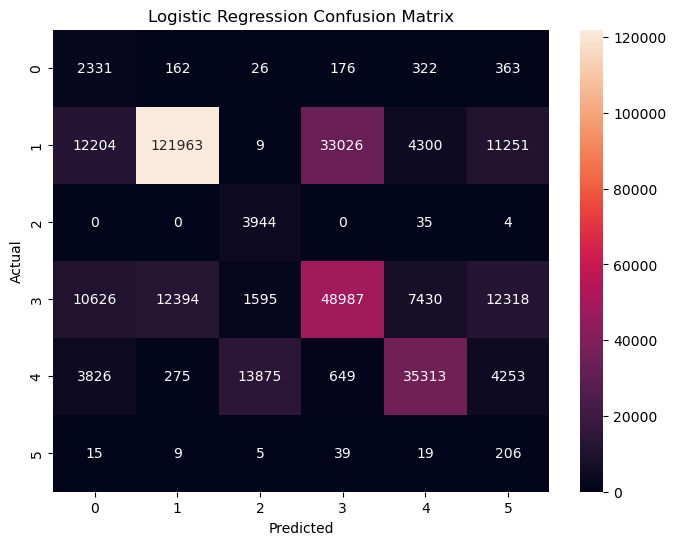

In [114]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

# Modelo 2 - Random Forest
O Random Forest é um algoritmo baseado em múltiplas árvores de decisão. Cada árvore aprende padrões diferentes do conjunto de dados e a decisão final é obtida por votação entre todas as árvores.

Entre suas principais vantagens estão:

- Capacidade de capturar relações não lineares;
- Robustez a ruídos;
- Boa performance em bases complexas;
- Possibilidade de analisar importância das variáveis.

Espera-se que o Random Forest apresente desempenho superior à Regressão Logística.

In [121]:
rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=30,
            max_depth=15,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

In [123]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['net_weight_kg',
                                                   'fob_value_usd',
                                                   'value_per_kg',
                                                   'statistical_quantity_export',
                                                   'month', 'quarter',
                                                   'semester', 'ncm_chapter',
                                                   'is_mercosul',
                                                   'is_coastal_state',
                                                   'is_express_delivery']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['origin_state',
                                                   'origin_region',
                                                   'country_name'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=30, n_jobs=-1,
                                        random_state=42))])

In [125]:
y_pred_rf = rf_pipeline.predict(
    X_test
)

## Avaliação do Random Forest
As mesmas métricas utilizadas na Regressão Logística são empregadas aqui para garantir uma comparação justa entre os modelos.

In [127]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_f1_macro = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

rf_f1_weighted = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Accuracy:", rf_accuracy)
print("F1 Macro:", rf_f1_macro)
print("F1 Weighted:", rf_f1_weighted)

Accuracy: 0.7491124433396695
F1 Macro: 0.5250947687442936
F1 Weighted: 0.7685265703788738


In [129]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.22      0.76      0.35      3380
           1       0.95      0.73      0.82    182753
          15       0.25      0.98      0.39      3983
           4       0.63      0.80      0.71     93350
           7       0.79      0.70      0.74     58191
       Other       0.07      0.77      0.14       293

    accuracy                           0.75    341950
   macro avg       0.49      0.79      0.53    341950
weighted avg       0.82      0.75      0.77    341950



### Matriz de Confusão

A matriz de confusão apresenta os acertos e erros do modelo para cada classe. Os valores presentes na diagonal principal representam classificações corretas, enquanto os demais valores representam confusões entre categorias.

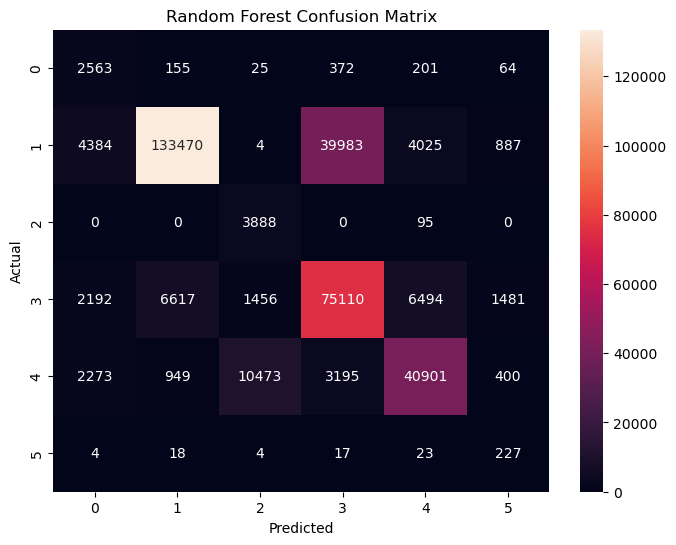

In [131]:
cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

# Otimização de Hiperparâmetros - Grid Search (tuning)
Após o treinamento inicial do Random Forest, é realizado um processo de ajuste de hiperparâmetros utilizando Grid Search. O objetivo é identificar a combinação de parâmetros que produz o melhor desempenho de classificação.

In [134]:
param_grid = {
    "classifier__n_estimators": [20, 30],
    "classifier__max_depth": [12, 15]
}

In [136]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

## Busca dos Melhores Parâmetros

O Grid Search avalia diferentes combinações de hiperparâmetros por meio de validação cruzada. Essa abordagem reduz a dependência de uma única divisão treino/teste e aumenta a confiabilidade da seleção do modelo.

In [138]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['net_weight_kg',
                                                                          'fob_value_usd',
                                                                          'value_per_kg',
                                                                          'statistical_quantity_export',
                                                                          'month',
                                                                          'quarter',
                                                                          'semester',
                                                                          'ncm_chapter',
                                                                          'is_mercosul',
                                                                          'is_coastal_state',
                                                                          'is_ex...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['origin_state',
                                                                          'origin_region',
                                                                          'country_name'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               max_depth=15,
                                                               n_estimators=30,
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [12, 15],
                         'classifier__n_estimators': [20, 30]},
             scoring='f1_weighted', verbose=2)

## Avaliação do Modelo Otimizado
Após identificar a melhor configuração, o modelo é novamente avaliado utilizando o conjunto de teste. Os resultados serão comparados com os modelos anteriores para verificar se houve ganho de desempenho.

In [140]:
print(grid_search.best_params_)

{'classifier__max_depth': 15, 'classifier__n_estimators': 30}


In [142]:
best_rf = grid_search.best_estimator_

In [144]:
y_pred_best_rf = best_rf.predict(
    X_test
)

In [146]:
best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

best_rf_f1_macro = f1_score(
    y_test,
    y_pred_best_rf,
    average="macro"
)

best_rf_f1_weighted = f1_score(
    y_test,
    y_pred_best_rf,
    average="weighted"
)

print("Accuracy:", best_rf_accuracy)
print("F1 Macro:", best_rf_f1_macro)
print("F1 Weighted:", best_rf_f1_weighted)

Accuracy: 0.7491124433396695
F1 Macro: 0.5250947687442936
F1 Weighted: 0.7685265703788738


In [148]:
print(
    classification_report(
        y_test,
        y_pred_best_rf
    )
)

              precision    recall  f1-score   support

           0       0.22      0.76      0.35      3380
           1       0.95      0.73      0.82    182753
          15       0.25      0.98      0.39      3983
           4       0.63      0.80      0.71     93350
           7       0.79      0.70      0.74     58191
       Other       0.07      0.77      0.14       293

    accuracy                           0.75    341950
   macro avg       0.49      0.79      0.53    341950
weighted avg       0.82      0.75      0.77    341950



## Matriz de Confusão

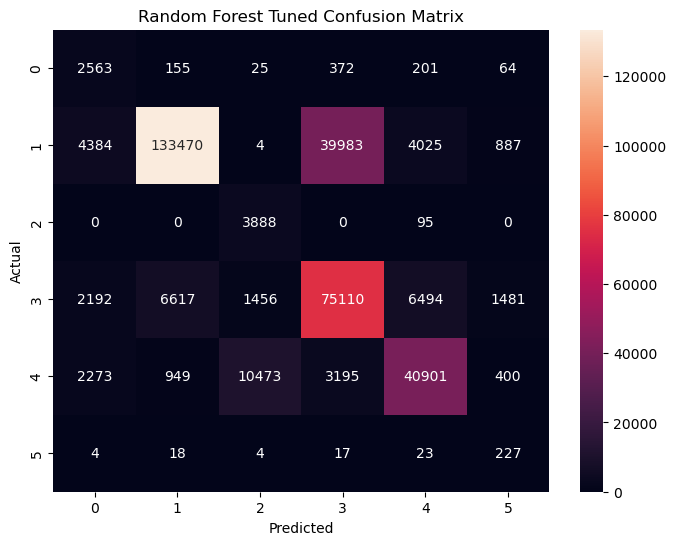

In [150]:
cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Random Forest Tuned Confusion Matrix"
)

plt.ylabel("Actual")
plt.xlabel("Predicted")

plt.show()

# Importância das Variáveis
A tabela apresenta as variáveis mais relevantes para a classificação da via de transporte. Valores mais elevados indicam maior contribuição para as decisões tomadas pelo modelo.

In [153]:
feature_names = (
    best_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    best_rf
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
212,cat__country_name_Paraguai,0.171752
8,num__is_mercosul,0.132186
7,num__ncm_chapter,0.082896
25,cat__origin_state_PA,0.064458
1,num__fob_value_usd,0.061905
2,num__value_per_kg,0.058117
0,num__net_weight_kg,0.048786
67,cat__country_name_Bolívia,0.037170
40,cat__origin_region_North,0.034712
3,num__statistical_quantity_export,0.027174


In [155]:
top_features = importance_df.head(15)

top_features

,feature,importance
212,cat__country_name_Paraguai,0.171752
8,num__is_mercosul,0.132186
7,num__ncm_chapter,0.082896
25,cat__origin_state_PA,0.064458
1,num__fob_value_usd,0.061905
2,num__value_per_kg,0.058117
0,num__net_weight_kg,0.048786
67,cat__country_name_Bolívia,0.037170
40,cat__origin_region_North,0.034712
3,num__statistical_quantity_export,0.027174


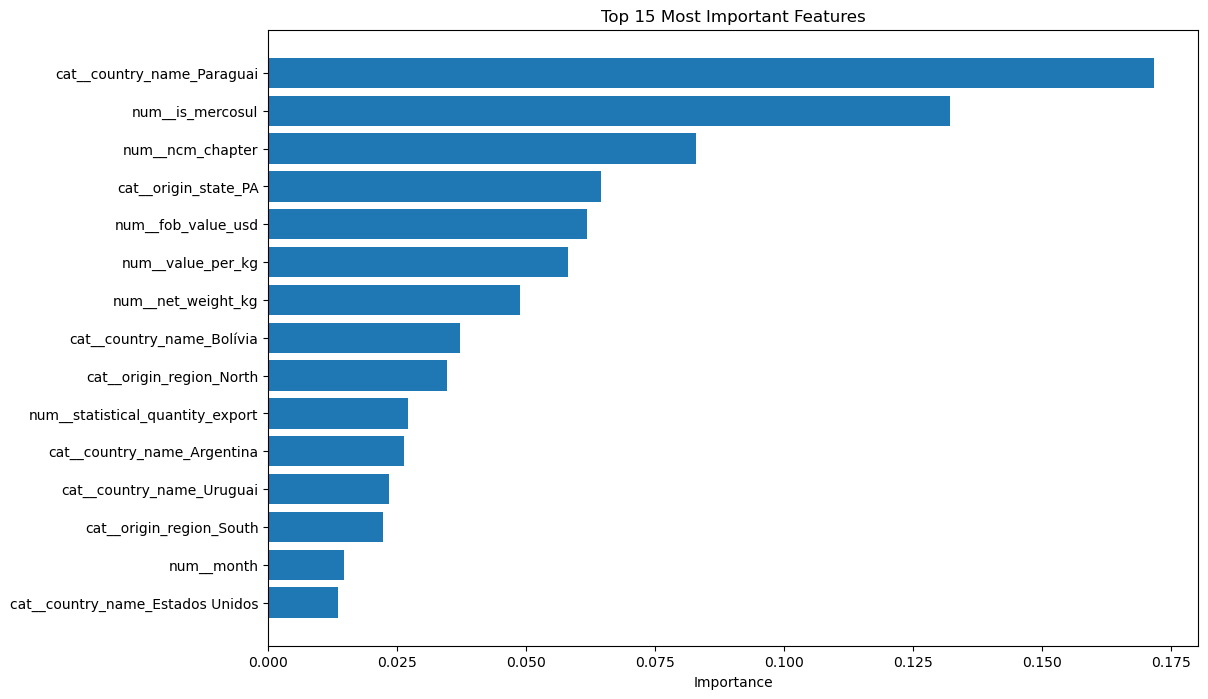

In [157]:
plt.figure(figsize=(12,8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Most Important Features"
)

plt.xlabel("Importance")

plt.show()

# Comparação Final dos Modelos

Os modelos são comparados utilizando as métricas de desempenho calculadas anteriormente. Essa análise permite avaliar o trade-off entre simplicidade, interpretabilidade e capacidade preditiva.

In [159]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest Tuned"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        best_rf_accuracy
    ],
    "F1 Macro": [
        logistic_f1_macro,
        rf_f1_macro,
        best_rf_f1_macro
    ],
    "F1 Weighted": [
        logistic_f1_weighted,
        rf_f1_weighted,
        best_rf_f1_weighted
    ]
})

results.sort_values(
    by="F1 Weighted",
    ascending=False
)

,Model,Accuracy,F1 Macro,F1 Weighted
1,Random Forest,0.749112,0.525095,0.768527
2,Random Forest Tuned,0.749112,0.525095,0.768527
0,Logistic Regression,0.622149,0.414621,0.681455


# Discussão Inicial dos Resultados
## Análise Comparativa dos Modelos
A comparação entre os modelos demonstra que o aumento da complexidade do algoritmo resultou em ganhos significativos de desempenho.

* A Regressão Logística obteve Accuracy de 62,21% e F1 Weighted de 0,6815. Apesar de apresentar desempenho satisfatório para algumas classes, o modelo possui limitações para capturar relações complexas e não lineares entre as variáveis explicativas e a via de transporte utilizada.

* Por outro lado, o Random Forest alcançou Accuracy de 74,91% e F1 Weighted de 0,7685, representando um aumento de aproximadamente 12,7 pontos percentuais na taxa de acerto geral e um ganho de cerca de 12,8% na métrica F1 Weighted.

* Esse resultado indica que a escolha da via de transporte não depende apenas de relações lineares simples entre as variáveis analisadas. Existem interações mais complexas entre características da carga, localização geográfica e destino comercial, que são melhor capturadas pelo Random Forest.

* O modelo Random Forest Tuned apresentou desempenho idêntico ao modelo Random Forest original, indicando que os hiperparâmetros inicialmente escolhidos já representavam a melhor configuração dentro do espaço de busca avaliado.

## Análise das Métricas de Performance
A métrica Accuracy indica que aproximadamente três em cada quatro exportações tiveram sua via de transporte corretamente prevista pelo modelo Random Forest. Entretanto, devido ao desbalanceamento entre as classes, a Accuracy isoladamente não é suficiente para avaliar o desempenho do modelo. Por esse motivo também foram analisadas as métricas F1 Macro e F1 Weighted.

O F1 Weighted apresentou valor de 0,7685, demonstrando bom desempenho geral considerando a distribuição real das classes. Já o F1 Macro atingiu 0,5251, valor inferior ao F1 Weighted. Essa diferença evidencia que o modelo possui maior dificuldade em prever corretamente as classes menos representativas, situação esperada devido ao desbalanceamento encontrado.

Dessa forma, conclui-se que o modelo apresenta bom desempenho para as categorias mais frequentes, mas ainda encontra dificuldades para distinguir adequadamente as classes raras.

## Análise da Matriz de Confusão
A matriz de confusão demonstra que a maior parte dos acertos está concentrada na diagonal principal, indicando que o modelo consegue identificar corretamente as principais categorias de transporte. As classes mais representativas do conjunto de dados, especialmente as rotas 1, 4 e 7, apresentaram os maiores números absolutos de classificações corretas. Observa-se também que as classes menos frequentes apresentam maiores taxas de confusão com outras categorias. Esse comportamento é esperado devido à baixa quantidade de exemplos disponíveis para treinamento dessas classes.

Apesar dessas dificuldades, o modelo conseguiu manter níveis elevados de recall para algumas categorias minoritárias, demonstrando capacidade de identificar parte significativa dos registros pertencentes a essas classes.

## Análise da Importância das Variáveis
A análise de importância das variáveis permitiu identificar quais características mais influenciaram a previsão da via de transporte.

As variáveis mais relevantes foram:

- País de destino (Paraguai);
- Indicador de pertencimento ao Mercosul;
- Capítulo NCM do produto;
- Estado de origem (Pará);
- Valor FOB da exportação;
- Valor por quilograma;
- Peso líquido da carga.

Os resultados indicam que fatores geográficos e comerciais exercem papel fundamental na determinação do modal de transporte utilizado. O destaque das variáveis relacionadas ao país de destino e ao Mercosul sugere que a proximidade geográfica e as relações comerciais regionais influenciam fortemente a logística das exportações brasileiras. 

Além disso, a elevada importância do capítulo NCM demonstra que o tipo de produto exportado também afeta diretamente a escolha da via de transporte, uma vez que diferentes mercadorias possuem requisitos logísticos específicos.

## Limitações
Algumas limitações devem ser consideradas:

- Presença de desbalanceamento entre as classes da variável alvo;
- Agrupamento das categorias raras na classe Other;

# Resposta - Pergunta de Pesquisa e Hipótese
## Pergunta de Pesquisa
O objetivo deste trabalho foi desenvolver um modelo capaz de prever a via de transporte utilizada em operações de exportação a partir das características da carga e da operação comercial. Os resultados demonstraram que essa previsão é possível com desempenho satisfatório. O modelo Random Forest atingiu aproximadamente 75% de acurácia, indicando que as variáveis disponíveis contêm informações relevantes para explicar a escolha do modal de transporte.

Portanto, conclui-se que características relacionadas ao produto exportado, ao valor da operação e ao contexto geográfico são capazes de explicar grande parte da decisão logística observada nos dados históricos.

## Hipótese
- O peso da carga (KG_LIQUIDO) e a origem geográfica (SG_UF_NCM) influenciam mais a escolha da via de transporte do que o valor FOB.

A hipótese proposta foi parcialmente confirmada pelos resultados obtidos. As variáveis relacionadas à localização geográfica apresentaram elevada relevância para o modelo, especialmente o país de destino, o indicador de pertencimento ao Mercosul, a região de origem e determinados estados exportadores.

Entretanto, o peso líquido da carga não se destacou como a variável mais importante do modelo. Além disso, o valor FOB apresentou importância superior à observada para o peso líquido.

Dessa forma, os resultados sugerem que a escolha da via de transporte depende mais fortemente de fatores geográficos e comerciais do que exclusivamente das características físicas da carga. A hipótese foi confirmada no que se refere à relevância da origem geográfica, mas não foi totalmente confirmada em relação à predominância do peso da carga sobre o valor FOB.
